In [83]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
from phik import phik_matrix
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [84]:
raw_customer_data = pd.read_csv('../../data/raw_data/customer_data.csv')

### Информация о признаках (перевод с английского):

1. **Balance** — Остаток на счете.  

2. **Balance Frequency** — Частота обновления остатка на счете.  

3. **Purchases** — Общая сумма покупок.  

4. **One-off Purchases** — Сумма разовых покупок.  

5. **Installment Purchases** — Сумма покупок в рассрочку.  

6. **Cash Advance** — Сумма снятия наличных.  

7. **Purchases Frequency** — Частота покупок.  

8. **One-off Purchases Frequency** — Частота разовых покупок.  

9. **Purchases Installments Frequency** — Частота покупок в рассрочку.  

10. **Cash Advance Frequency** — Частота снятия наличных.  

11. **Cash Advance TRX** — Количество операций снятия наличных.  

12. **Purchases TRX** — Количество операций покупок.  

13. **Credit Limit** — Кредитный лимит.  

14. **Payments** — Общая сумма платежей.  

15. **Minimum Payments** — Минимальная сумма платежей.  

16. **PRC Full payment** — Процент полного погашения задолженности.  

17. **Tenure** — Срок обслуживания клиента (в месяцах). 

In [85]:
raw_customer_data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


#### Удалим CUST_ID, так как он не несет в себе никакой информации


In [86]:
raw_customer_data.drop('CUST_ID', axis=1, inplace=True)

### Проанализируем общую информацию о данных

In [87]:
raw_customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [88]:
raw_customer_data.nunique()

BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [89]:
raw_customer_data.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [90]:
raw_customer_data.duplicated().sum()

0

### Проверим наличие пропущенных значений

In [91]:
missing_values = raw_customer_data.isnull().sum()

missing_percentage = (missing_values / len(raw_customer_data) * 100).round(2)

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

print(missing_data)

                                  Missing Values  Percentage
BALANCE                                        0        0.00
BALANCE_FREQUENCY                              0        0.00
PURCHASES                                      0        0.00
ONEOFF_PURCHASES                               0        0.00
INSTALLMENTS_PURCHASES                         0        0.00
CASH_ADVANCE                                   0        0.00
PURCHASES_FREQUENCY                            0        0.00
ONEOFF_PURCHASES_FREQUENCY                     0        0.00
PURCHASES_INSTALLMENTS_FREQUENCY               0        0.00
CASH_ADVANCE_FREQUENCY                         0        0.00
CASH_ADVANCE_TRX                               0        0.00
PURCHASES_TRX                                  0        0.00
CREDIT_LIMIT                                   1        0.01
PAYMENTS                                       0        0.00
MINIMUM_PAYMENTS                             313        3.50
PRC_FULL_PAYMENT        

#### Посмотрим на строку CREDIT_LIMIT с пропущенными значениями

In [92]:
raw_customer_data[raw_customer_data['CREDIT_LIMIT'].isnull()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


#### Найдем наиболее похожую строку на строку с пропущенными значениями

Для этого необходимо убрать пропущенные значения в остальных данных. Так как в MIMIMUM_PAYMENTS пропущено 3.5% значений, то просто удалим их. Кроме того, нормализуем данные, чтобы они находились в одном диапазоне.

In [93]:
cleaned_MINIMUM_PAYMENTS_customer_data = raw_customer_data.dropna(subset=['MINIMUM_PAYMENTS'])

scaler = StandardScaler()
scaled_cleaned_data = scaler.fit_transform(cleaned_MINIMUM_PAYMENTS_customer_data)

missing_credit_limit = raw_customer_data[raw_customer_data['CREDIT_LIMIT'].isnull()]

missing_scaled_data = scaler.transform(missing_credit_limit)

distances = cdist(missing_scaled_data, scaled_cleaned_data, metric='euclidean')

closest_indices = np.argmin(distances, axis=1)

closest_row = cleaned_MINIMUM_PAYMENTS_customer_data.iloc[closest_indices]

closest_row

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.4,0.0,95.4,0.0,0.166667,0.0,0.083333,0.0,0,2,1000.0,201.802084,139.509787,0.0,12


In [94]:
closest_rows_scaled = pd.DataFrame(
    scaled_cleaned_data[closest_indices],
    columns=cleaned_MINIMUM_PAYMENTS_customer_data.columns
)

print("Наиболее близкие строки из масштабированных данных:")
closest_rows_scaled

Наиболее близкие строки из масштабированных данных:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744556,-0.369399,-0.429148,-0.359137,-0.354789,-0.468635,-0.820601,-0.686221,-0.717078,-0.682008,-0.479423,-0.517573,-0.962575,-0.543891,-0.305482,-0.537687,0.355324


In [95]:
missing_row_scaled = pd.DataFrame(
    missing_scaled_data,
    columns=cleaned_MINIMUM_PAYMENTS_customer_data.columns
)

print("\nСтрока с пропущенным CREDIT_LIMIT (в масштабированном виде):")
missing_row_scaled


Строка с пропущенным CREDIT_LIMIT (в масштабированном виде):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.755294,-3.504386,-0.473175,-0.359137,-0.458807,-0.380548,-1.235958,-0.686221,-0.926422,0.144024,-0.334742,-0.597007,NaN,-0.610143,-0.358211,-0.537687,-4.217207


#### Заполним пропущенные значения в CREDIT_LIMIT наиболее похожими значениями

In [96]:
customer_data_filled_credit_limit = raw_customer_data.copy()

missing_index = raw_customer_data[raw_customer_data['CREDIT_LIMIT'].isnull()].index[0]

customer_data_filled_credit_limit.at[missing_index, 'CREDIT_LIMIT'] = closest_row['CREDIT_LIMIT']

customer_data_filled_credit_limit.loc[missing_index][['CREDIT_LIMIT']]

CREDIT_LIMIT    1000.0
Name: 5203, dtype: float64

#### Удалим более не используемые переменные

In [97]:
raw_customer_data = customer_data_filled_credit_limit.copy()

In [98]:
del missing_values
del missing_percentage
del missing_data
del cleaned_MINIMUM_PAYMENTS_customer_data
del scaler
del scaled_cleaned_data
del missing_credit_limit
del missing_scaled_data
del distances
del closest_indices
del closest_row
del closest_rows_scaled
del missing_row_scaled
del customer_data_filled_credit_limit
del missing_index

#### Рассмотрим пропуски в MINIMUM_PAYMENTS


1. Посмотрим на несколько строк с пропущенными значениями в MINIMUM_PAYMENTS

In [99]:
raw_customer_data[raw_customer_data['MINIMUM_PAYMENTS'].isnull()].head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,1666.670542,0.636364,1499.0,1499.0,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,2242.311686,1.000000,437.0,97.0,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,3910.111237,1.000000,0.0,0.0,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,6.660517,0.636364,310.0,0.0,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,1311.995984,1.000000,1283.9,1283.9,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12


2. Посмотрим на распределение MINIMUM_PAYMENTS

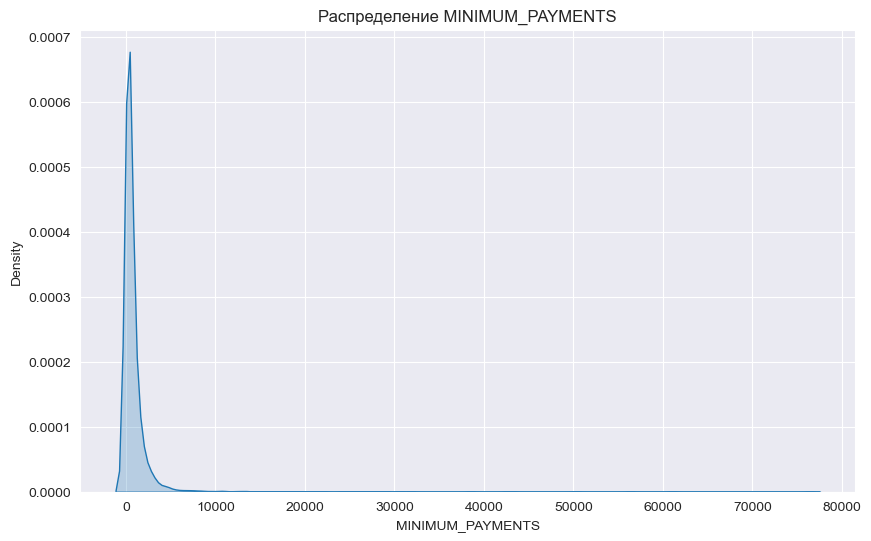

In [100]:
plt.figure(figsize=(10, 6))
sns.kdeplot(raw_customer_data['MINIMUM_PAYMENTS'], fill=True)
plt.title('Распределение MINIMUM_PAYMENTS')
plt.show()

Видим, что основная часть находится в диапазоне от 0 до 10000

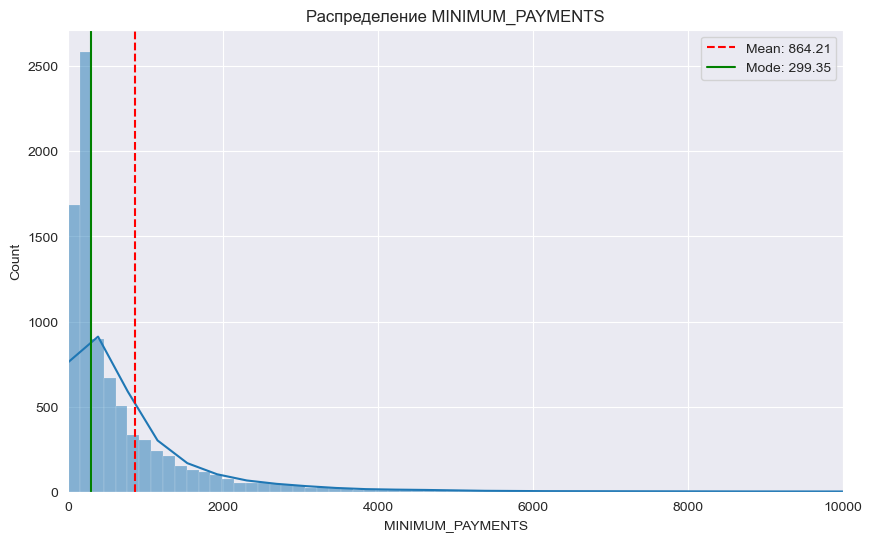

In [101]:
mean_value = raw_customer_data['MINIMUM_PAYMENTS'].mean()
mode_value = raw_customer_data['MINIMUM_PAYMENTS'].mode()[0]

plt.figure(figsize=(10, 6))
sns.histplot(raw_customer_data['MINIMUM_PAYMENTS'], kde=True, bins=500)
plt.xlim(0, 10000)
plt.title('Распределение MINIMUM_PAYMENTS')

plt.axvline(mean_value, color='r', linestyle='--', label=f'Mean: {mean_value:.2f}')
plt.axvline(mode_value, color='g', linestyle='-', label=f'Mode: {mode_value:.2f}')

plt.legend()
plt.show()

##### Как видим для пропущенных значений в признаке MINIMUM_PAYMENTS можно использовать моду, однако так как пропущено 3.5% значений, то просто удалим их

In [102]:
raw_customer_data.dropna(subset=['MINIMUM_PAYMENTS'], inplace=True)

### Посмотрим заново на данные

In [103]:
customer_data = raw_customer_data.copy()

del raw_customer_data

In [104]:
customer_data.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

#### Все пропущенные значения заполнены, либо удалены

### Теперь перейдем к выбросам в данных

In [105]:
outlier_percentage = {}

for column in customer_data.columns:
    Q1 = customer_data[column].quantile(0.25)
    Q3 = customer_data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((customer_data[column] < lower_bound) | (customer_data[column] > upper_bound))
    
    outlier_percentage[column] = (outliers.sum() / len(customer_data)) * 100

print("Процент выбросов по столбцам:")
for column, percentage in outlier_percentage.items():
    print(f"{column}: {percentage:.2f}%")

Процент выбросов по столбцам:
BALANCE: 7.71%
BALANCE_FREQUENCY: 17.51%
PURCHASES: 8.89%
ONEOFF_PURCHASES: 11.13%
INSTALLMENTS_PURCHASES: 9.39%
CASH_ADVANCE: 11.31%
PURCHASES_FREQUENCY: 0.00%
ONEOFF_PURCHASES_FREQUENCY: 8.67%
PURCHASES_INSTALLMENTS_FREQUENCY: 0.00%
CASH_ADVANCE_FREQUENCY: 3.95%
CASH_ADVANCE_TRX: 9.19%
PURCHASES_TRX: 8.29%
CREDIT_LIMIT: 2.81%
PAYMENTS: 9.09%
MINIMUM_PAYMENTS: 9.74%
PRC_FULL_PAYMENT: 15.55%
TENURE: 14.95%


#### Видим, что во всех столбцах с помощью квартильного метода обнаружены выбросы. Однако, выбросов достаточно много, чтобы удалять. Кроме того, это финансовые данные, которые могут играть ключевую роль в модели. Поподробнее проанализируем данные далее, а затем примем решение об удалении выбросов.

### Посмотрим на распределение данных

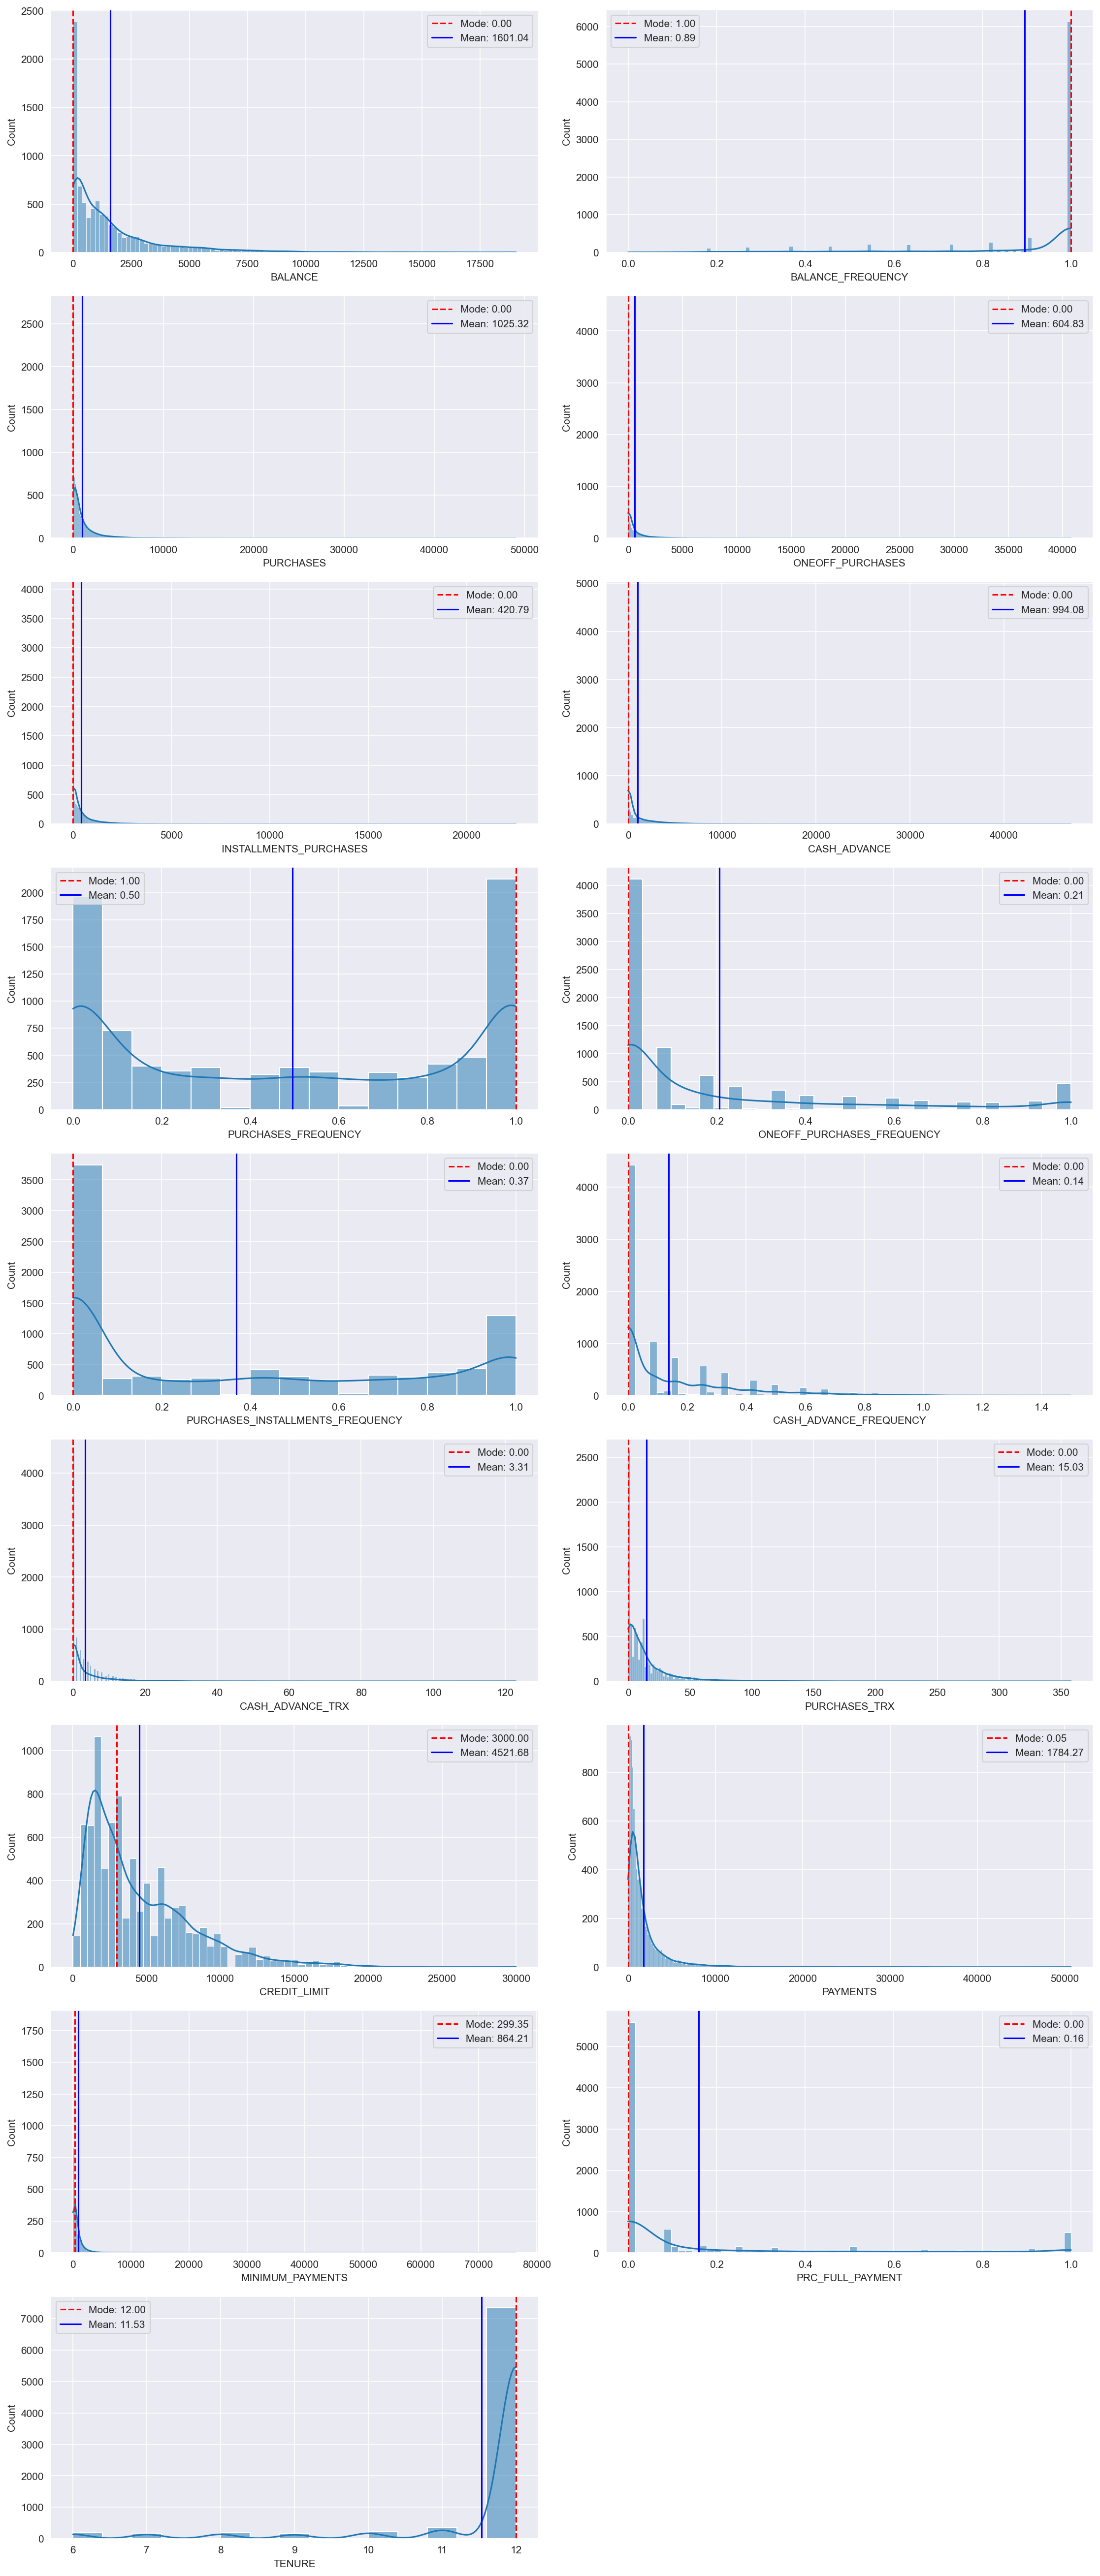

In [106]:
plt.figure(figsize=(15, 35), dpi=150)

for i, column in enumerate(customer_data.columns):
    plt.subplot(len(customer_data.columns) // 2 + 1, 2, i + 1)
    
    sns.histplot(customer_data[column], kde=True)
    
    mode_value = customer_data[column].mode()[0]
    mean_value = customer_data[column].mean()
    
    plt.axvline(mode_value, color='r', linestyle='--', label=f'Mode: {mode_value:.2f}')
    plt.axvline(mean_value, color='b', linestyle='-', label=f'Mean: {mean_value:.2f}')
    
    plt.legend()

plt.tight_layout()
plt.show()

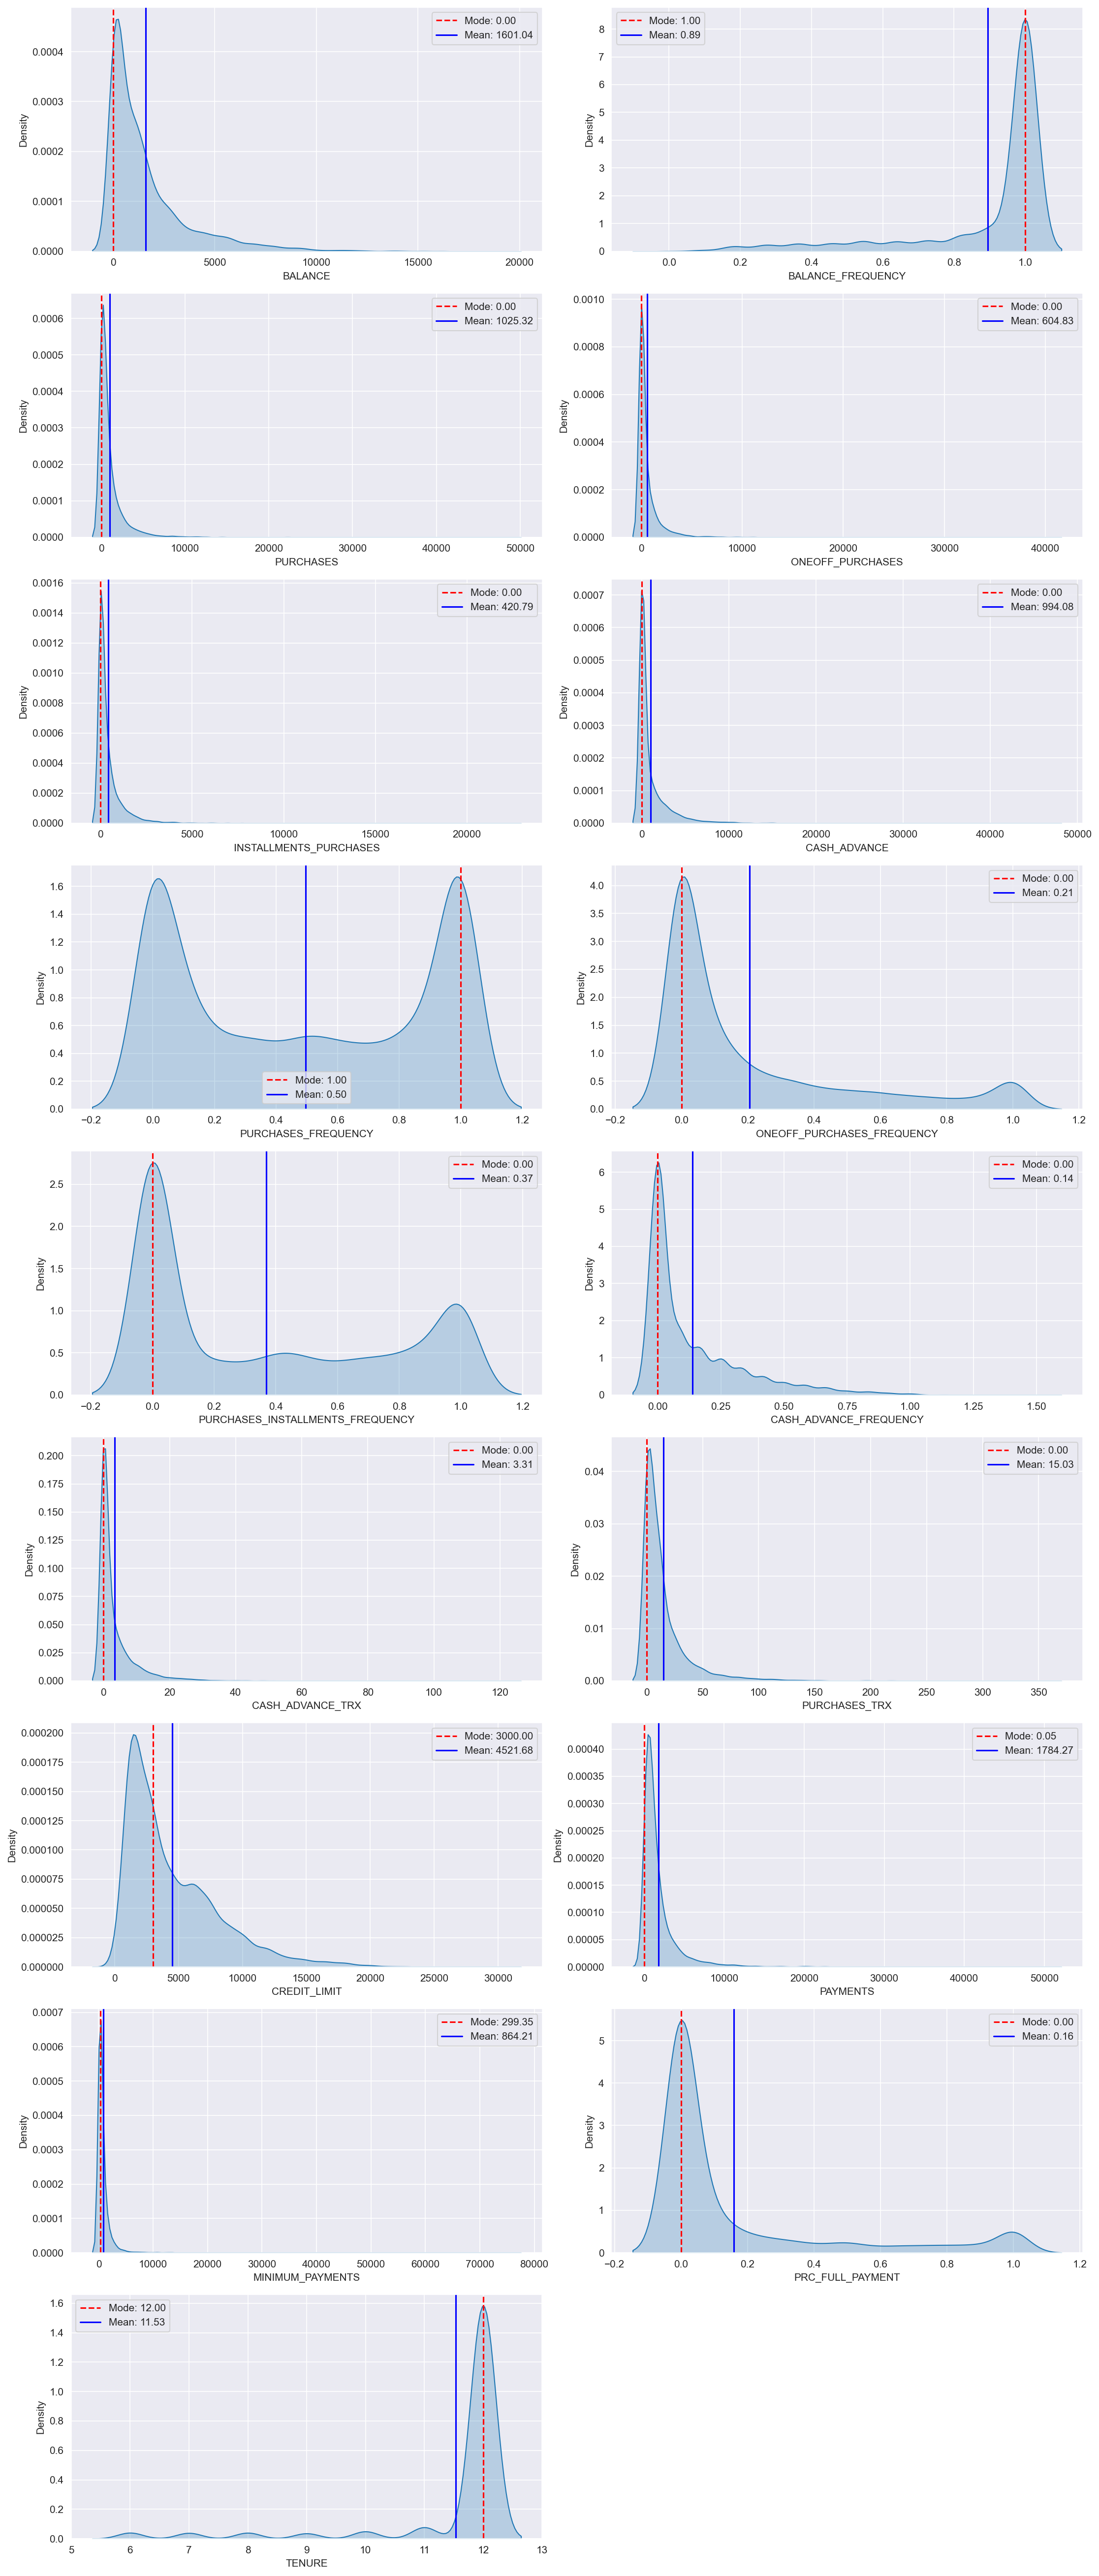

In [107]:
plt.figure(figsize=(15, 35), dpi=150)

for i, column in enumerate(customer_data.columns):
    plt.subplot(len(customer_data.columns) // 2 + 1, 2, i + 1)
    
    sns.kdeplot(customer_data[column], fill=True)
    
    mode_value = customer_data[column].mode()[0]
    mean_value = customer_data[column].mean()
    
    plt.axvline(mode_value, color='r', linestyle='--', label=f'Mode: {mode_value:.2f}')
    plt.axvline(mean_value, color='b', linestyle='-', label=f'Mean: {mean_value:.2f}')
    
    plt.legend()

plt.tight_layout()
plt.show()

#### Посмотрим QQ-графики для каждого признака

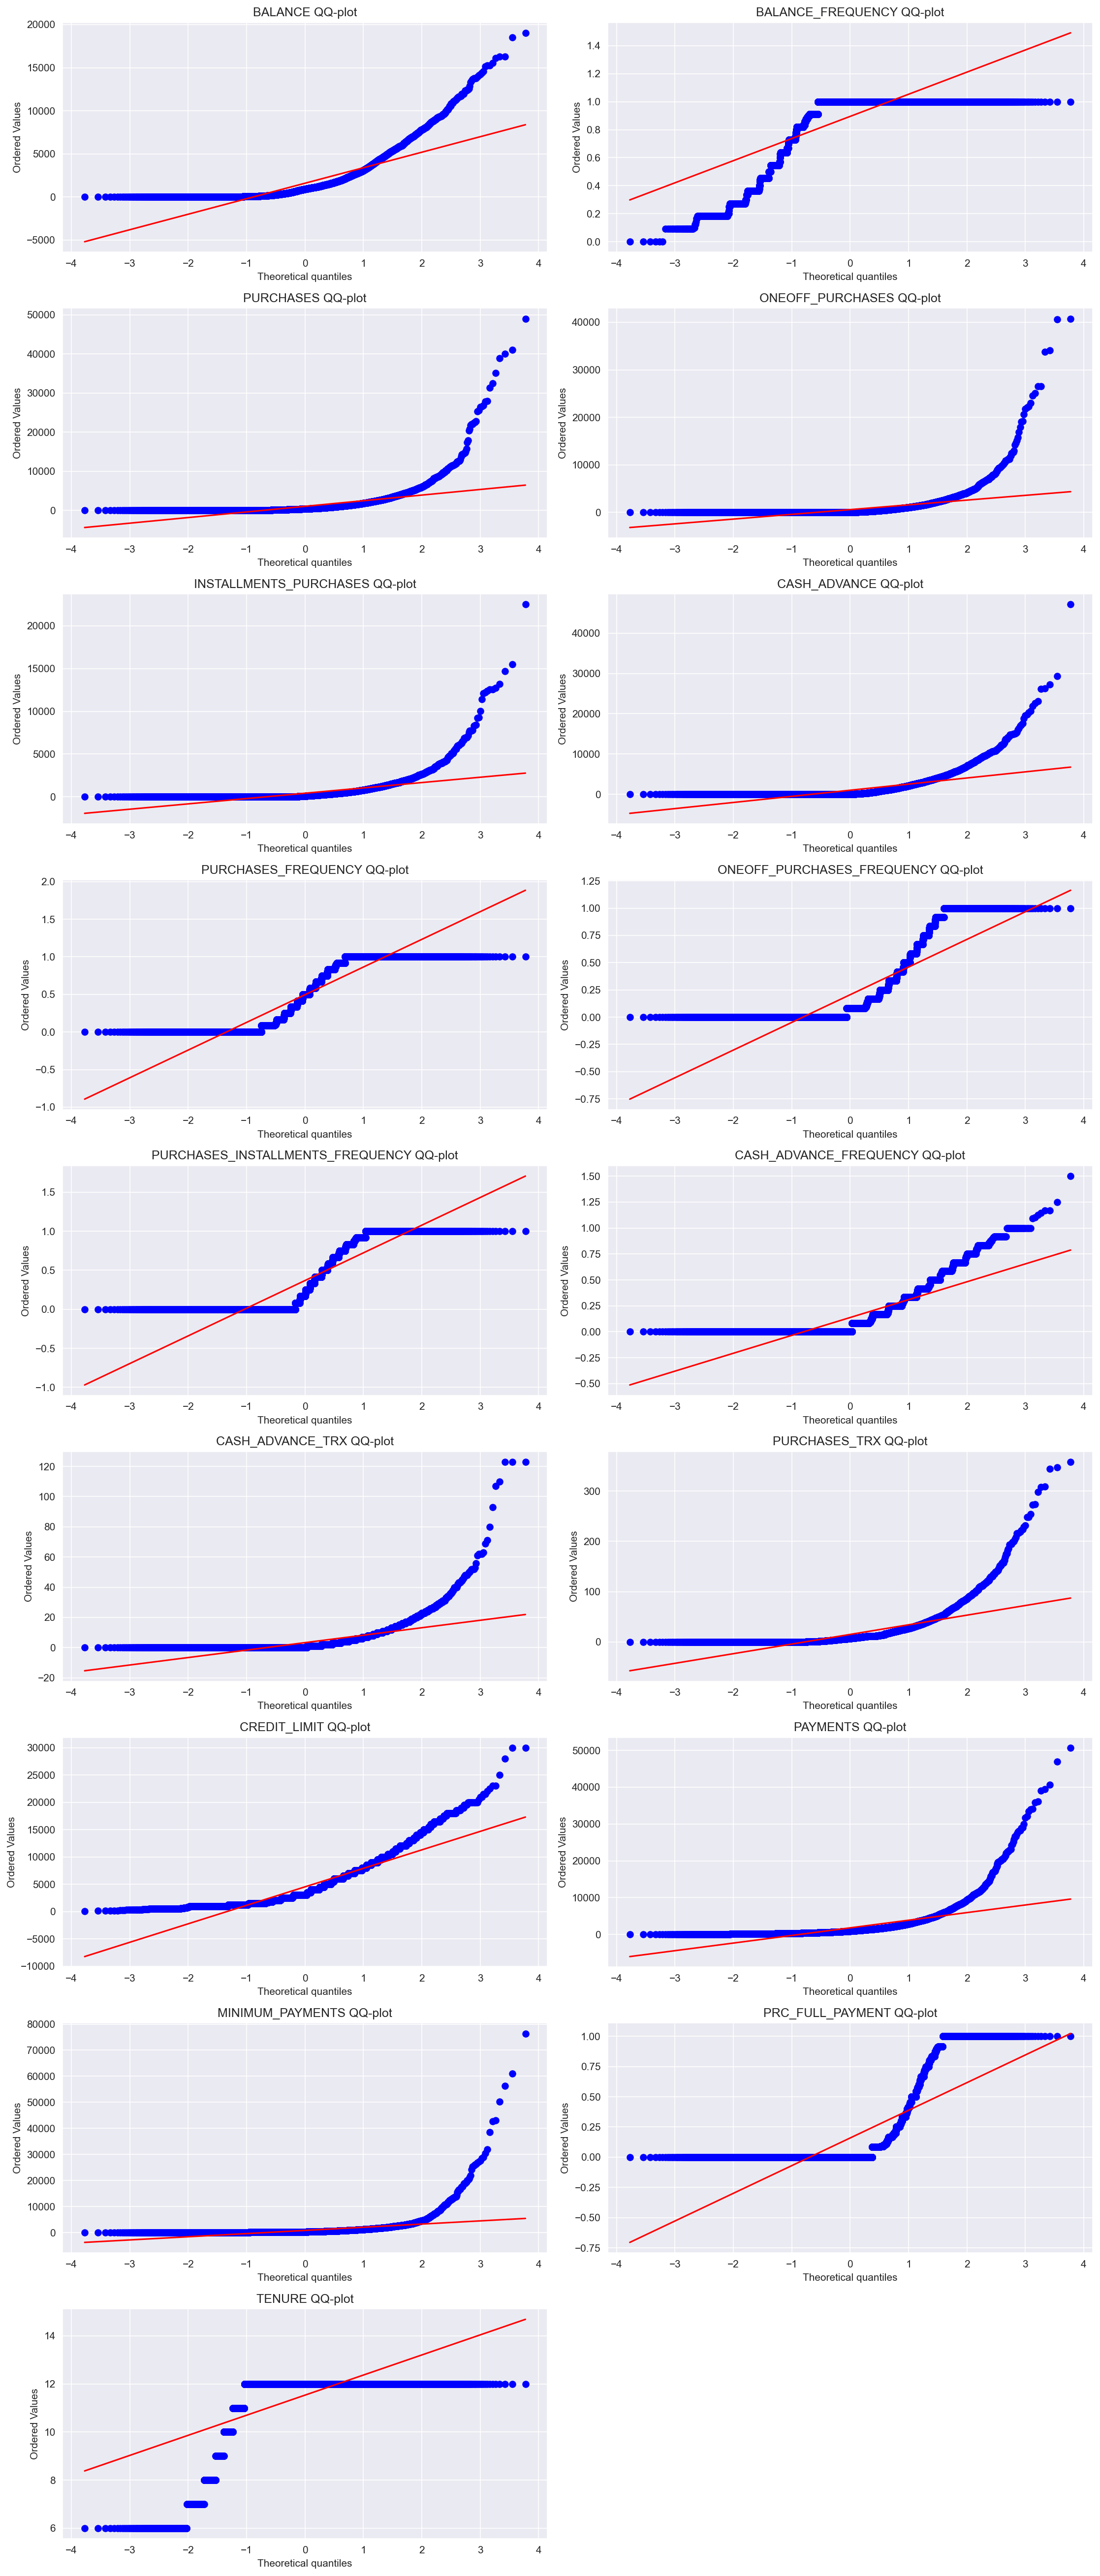

In [108]:
plt.figure(figsize=(15, 35), dpi=150)

for i, column in enumerate(customer_data.columns):
    plt.subplot(len(customer_data.columns) // 2 + 1, 2, i + 1)
    
    stats.probplot(customer_data[column], dist="norm", plot=plt)
        
    plt.title(f'{column} QQ-plot')
    
plt.tight_layout()
plt.show()

#### Как видим, у наших данных тяжелые хвосты. Попробуем прологарифмировать данные и посмотреть на QQ-графики заново

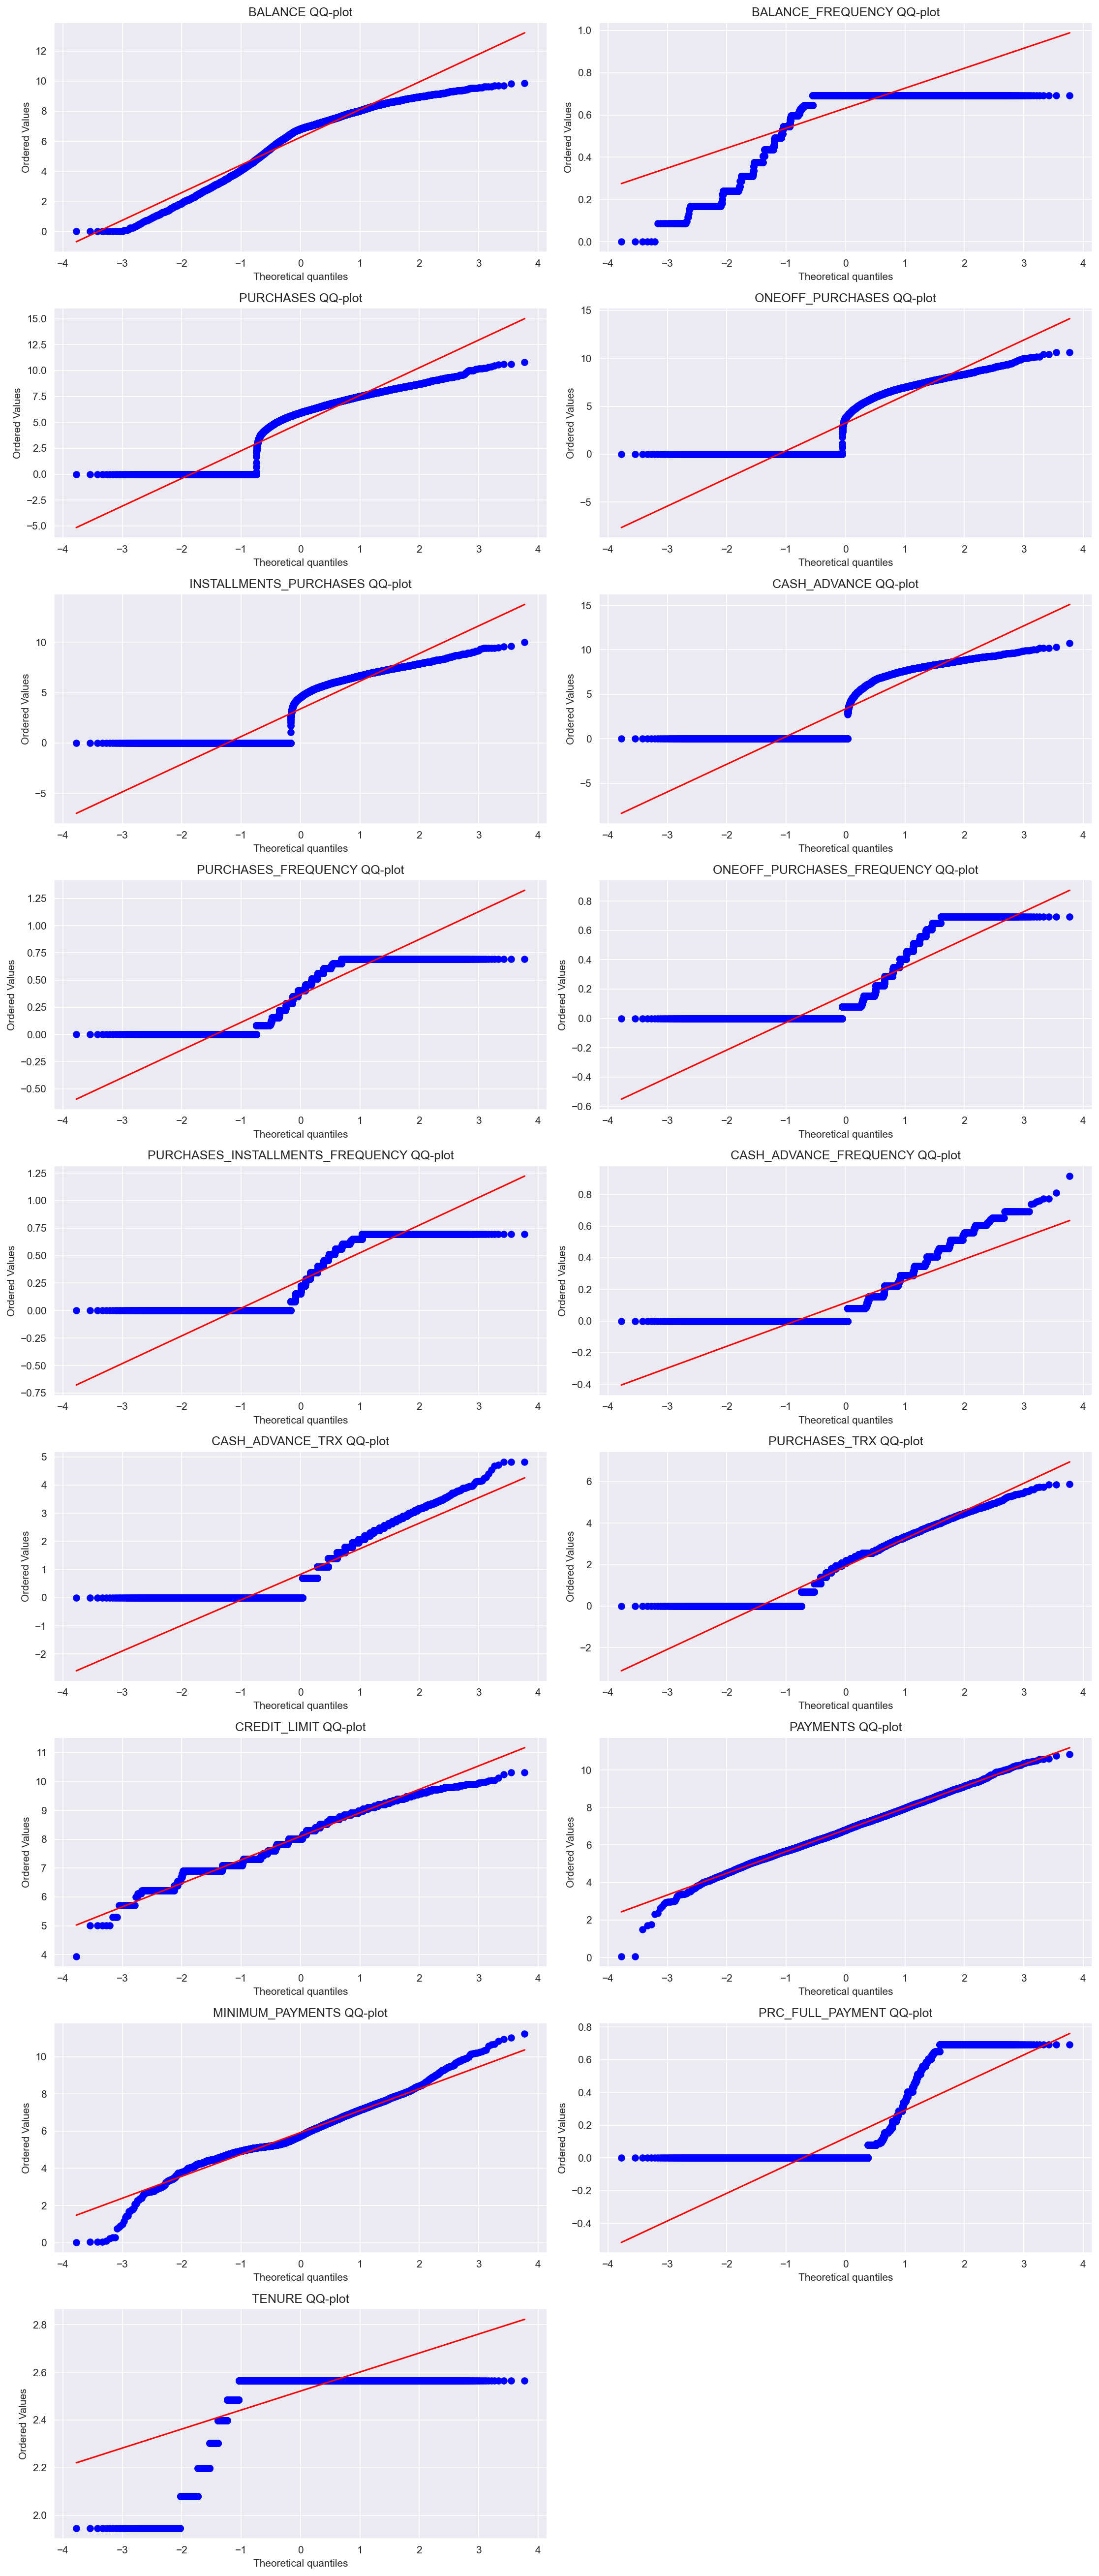

In [109]:
transformed_data = customer_data.apply(
    lambda x: np.log(x + 1) if x.name in customer_data.columns else x
)

plt.figure(figsize=(15, 35), dpi=150)

for i, column in enumerate(transformed_data.columns):
    plt.subplot(len(transformed_data.columns) // 2 + 1, 2, i + 1)
    
    stats.probplot(transformed_data[column], dist="norm", plot=plt)
        
    plt.title(f'{column} QQ-plot')
    
plt.tight_layout()
plt.show()

#### Видим существенные изменения в лучшую сторону

### Посмотрим на данные и применим нормализацию

In [110]:
transformed_data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.510826,0.000000,0.459532,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,2.564949


In [111]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(transformed_data)

scaled_data = pd.DataFrame(scaled_data, columns=transformed_data.columns)

scaled_data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.334348,-0.270075,-0.123104,-0.995909,0.382099,-0.937995,-0.761018,-0.740342,-0.684413,-0.731294,-0.817031,-0.593025,-1.447905,-1.293972,-0.820647,-0.569563,0.341918
1,0.952818,0.116261,-1.686076,-0.995909,-1.095968,1.518317,-1.317061,-0.740342,-0.968008,0.681694,0.768576,-1.389871,0.917344,1.296746,0.887361,0.367302,0.341918
2,0.821240,0.484620,0.589627,1.049267,-1.095968,-0.937995,1.183213,2.441043,-0.968008,-0.731294,-0.817031,0.470539,1.001230,-0.327094,0.437490,-0.569563,0.341918
3,0.233311,0.484620,-0.716780,-0.124802,-1.095968,-0.937995,-1.028337,-0.372966,-0.968008,-0.731294,-0.817031,-0.887118,-1.226399,-0.252615,-0.350894,-0.569563,0.341918
4,0.651964,0.484620,0.775861,-0.995909,1.232229,-0.937995,0.525555,-0.740342,0.660141,-0.731294,-0.817031,0.203820,-0.733677,0.370940,1.566214,-0.569563,0.341918


In [112]:
processed_customer_data = scaled_data.copy()
processed_customer_data.to_csv('../../data/processed_data/main_datasets/customer_data_processed.csv', index=False)

In [113]:
del outlier_percentage
del transformed_data
del scaled_data

### Рассмотрим взаимосвязи между признаками

1. Корреляция Пирсона

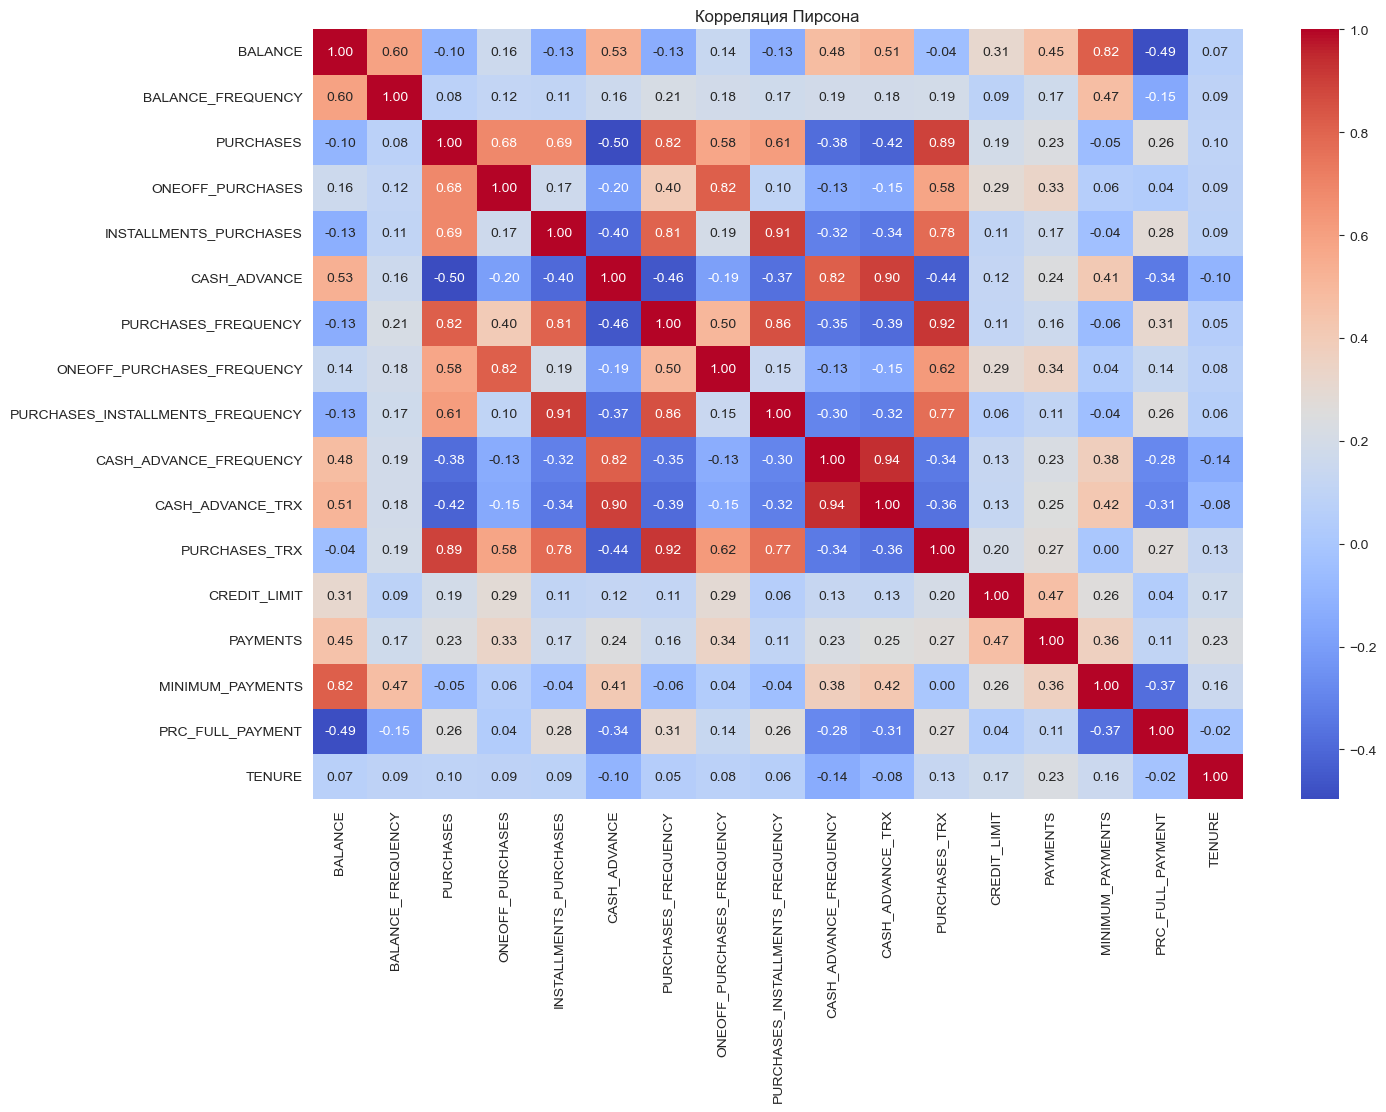

In [114]:
plt.figure(figsize=(15, 10))
sns.heatmap(processed_customer_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция Пирсона')
plt.show()

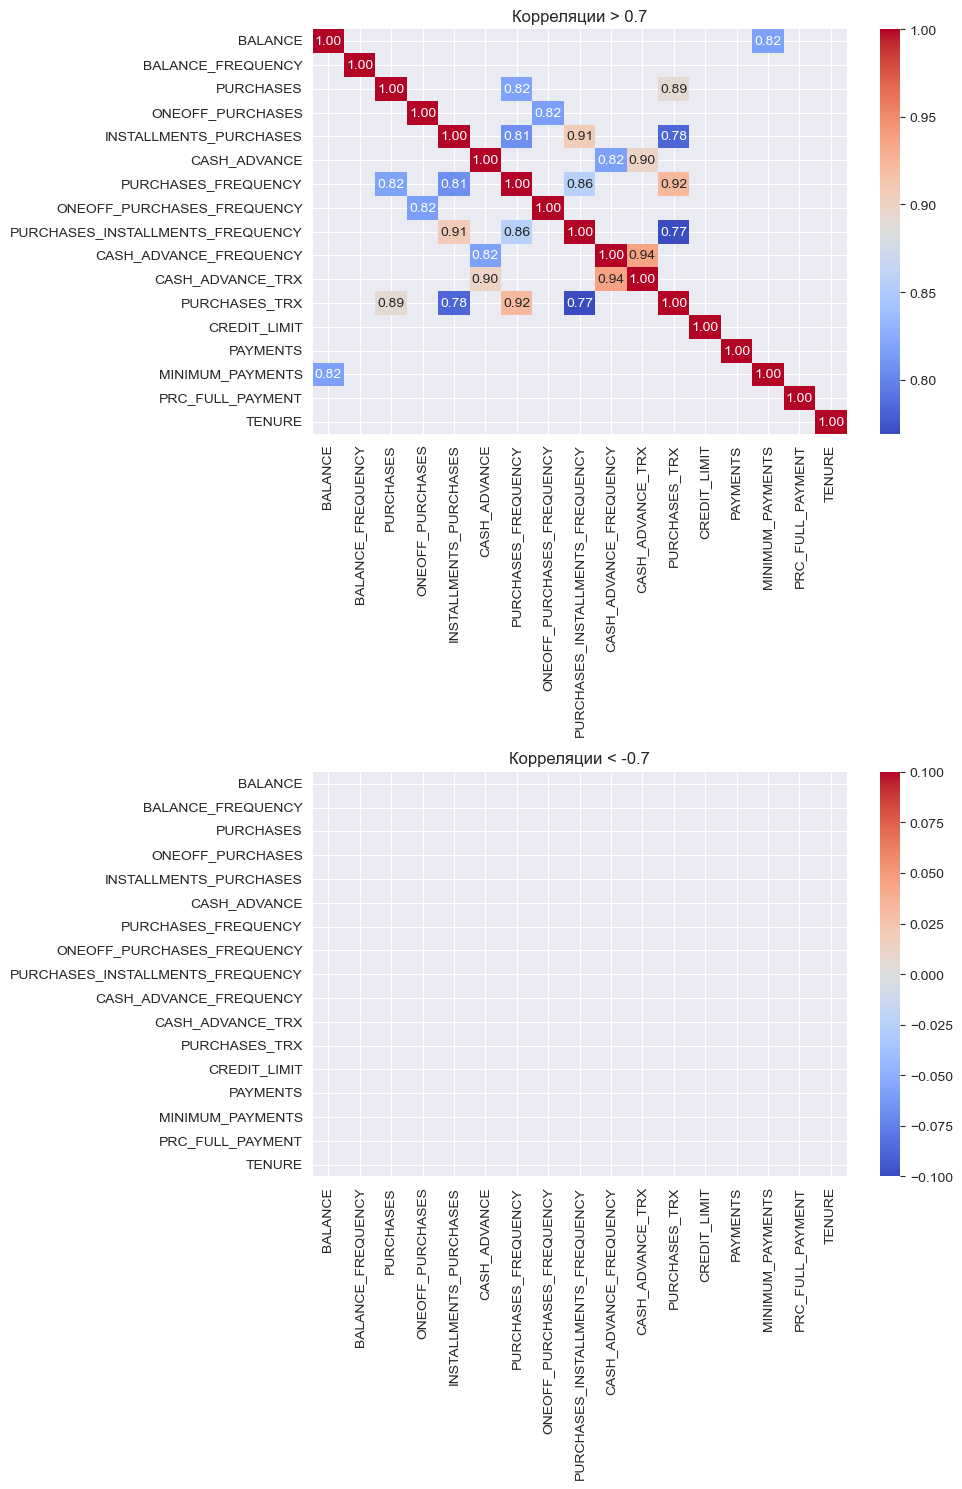

In [115]:
correlation_matrix = processed_customer_data.corr()

correlation_matrix_high = correlation_matrix[correlation_matrix > 0.7]
correlation_matrix_low = correlation_matrix[correlation_matrix < -0.7]

correlation_matrix_high = correlation_matrix_high.fillna(np.nan)
correlation_matrix_low = correlation_matrix_low.fillna(np.nan)

fig, axes = plt.subplots(2, 1, figsize=(10, 15))

sns.heatmap(correlation_matrix_high, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Корреляции > 0.7')

sns.heatmap(correlation_matrix_low, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Корреляции < -0.7')

plt.tight_layout()
plt.show()

Как видим по корреляции Пирсона, сильно коррелируют следующие признаки:

In [116]:
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs > 0.7]

corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] < corr_pairs['Feature 2']]
corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)

corr_pairs

,Feature 1,Feature 2,Correlation
28,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.937540
19,PURCHASES_FREQUENCY,PURCHASES_TRX,0.921647
10,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.906393
14,CASH_ADVANCE,CASH_ADVANCE_TRX,0.899353
5,PURCHASES,PURCHASES_TRX,0.891543
18,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.856321
4,PURCHASES,PURCHASES_FREQUENCY,0.818305
1,BALANCE,MINIMUM_PAYMENTS,0.816644
13,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.816433
7,ONEOFF_PURCHASES,ONEOFF_PURCHASES_FREQUENCY,0.815906


In [117]:
correlated_features = pd.Series(list(corr_pairs['Feature 1']) + list(corr_pairs['Feature 2']))

most_common_feature = correlated_features.value_counts().idxmax()

print(f"Самый часто встречающийся сильно коррелирующий признак: {most_common_feature}")

Самый часто встречающийся сильно коррелирующий признак: PURCHASES_FREQUENCY


#### Однако корреляция Пирсона рассматривает только линейные взаимосвязи, однако они очень редко встречаются в экономических данных. Поэтому рассмотрим Phik-корреляцию.

2. Корреляция Phik

interval columns not set, guessing: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


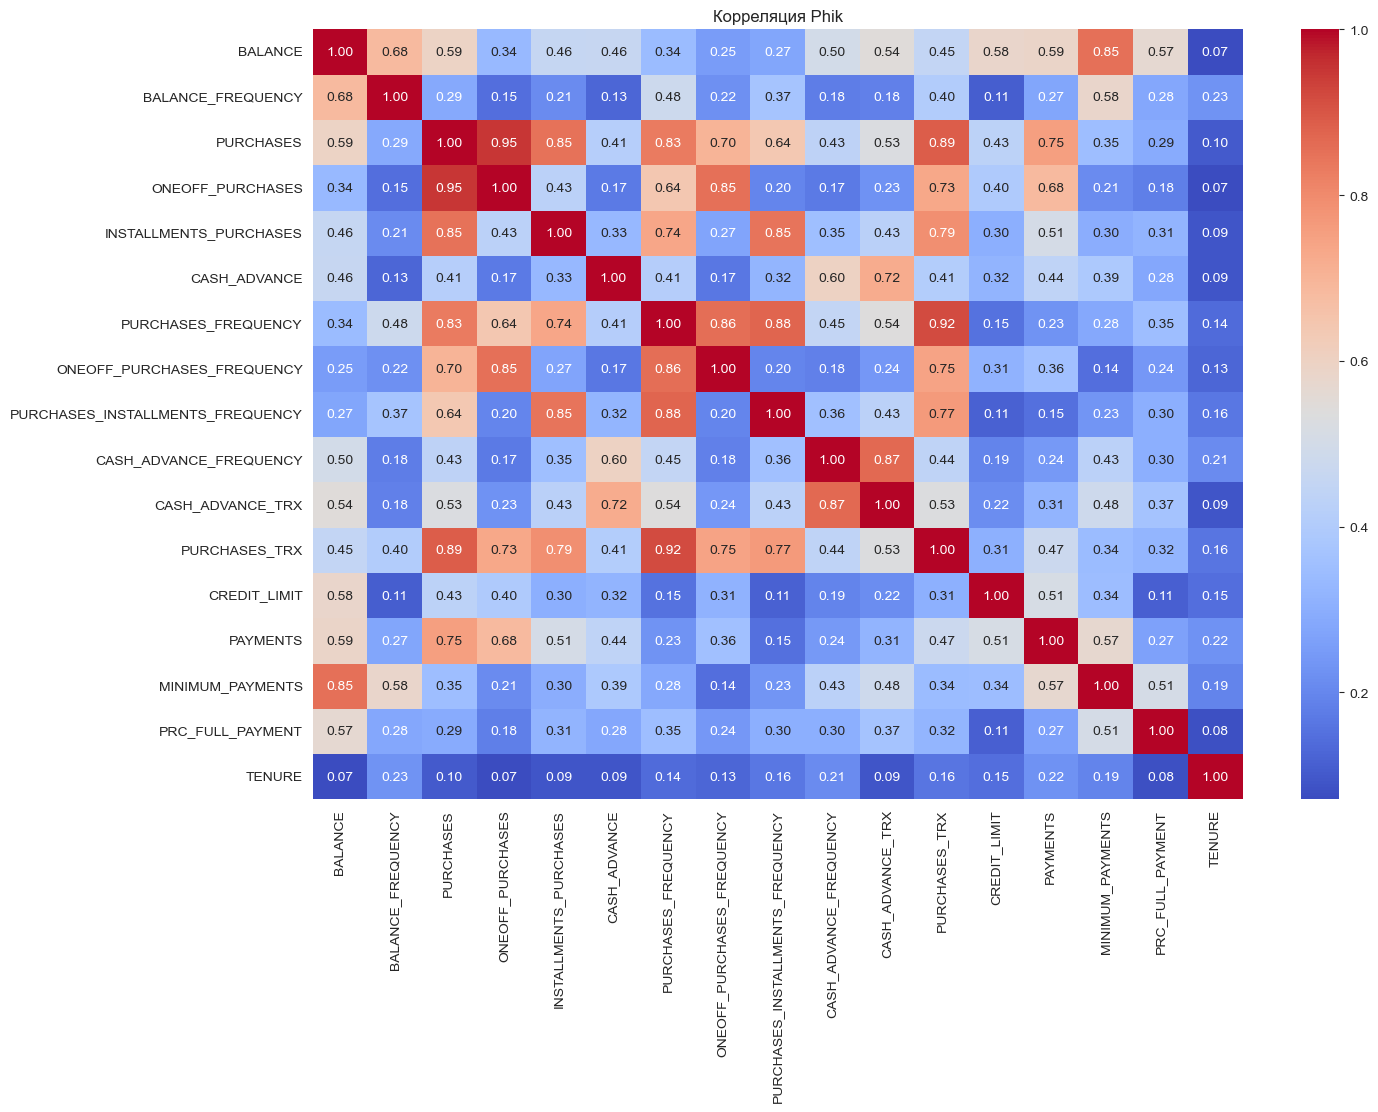

In [118]:
phik_corr_matrix = phik_matrix(processed_customer_data)

plt.figure(figsize=(15, 10))

sns.heatmap(phik_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Корреляция Phik')
plt.show()

interval columns not set, guessing: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


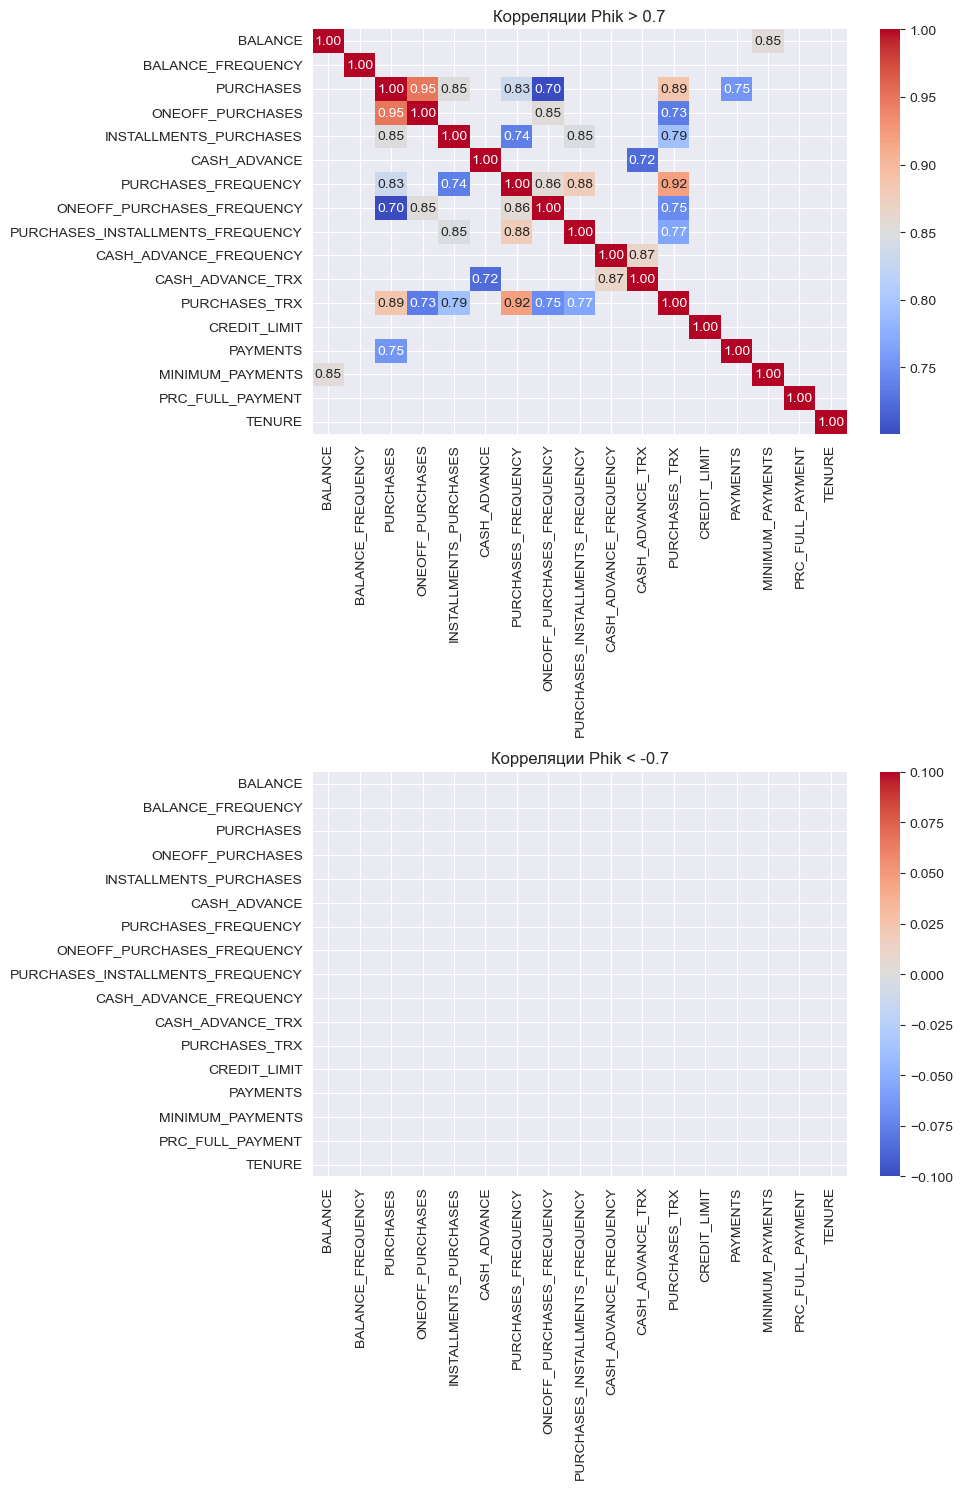

In [119]:
phik_matrix_data = processed_customer_data.phik_matrix()

phik_matrix_high = phik_matrix_data[phik_matrix_data > 0.7]
phik_matrix_low = phik_matrix_data[phik_matrix_data < -0.7]

phik_matrix_high = phik_matrix_high.fillna(np.nan)
phik_matrix_low = phik_matrix_low.fillna(np.nan)

fig, axes = plt.subplots(2, 1, figsize=(10, 15))

sns.heatmap(phik_matrix_high, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Корреляции Phik > 0.7')

sns.heatmap(phik_matrix_low, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Корреляции Phik < -0.7')

plt.tight_layout()
plt.show()

In [120]:
corr_pairs_phik = phik_matrix_data.unstack()
corr_pairs_phik = corr_pairs_phik[corr_pairs_phik > 0.7]
corr_pairs_phik = corr_pairs_phik.reset_index()
corr_pairs_phik.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs_phik['Correlation Type'] = 'Phik'
corr_pairs_phik = corr_pairs_phik[corr_pairs_phik['Feature 1'] < corr_pairs_phik['Feature 2']]

corr_pairs_phik = corr_pairs_phik.sort_values(by='Feature 1')

corr_pairs_phik

,Feature 1,Feature 2,Correlation,Correlation Type
1,BALANCE,MINIMUM_PAYMENTS,0.854559,Phik
20,CASH_ADVANCE,CASH_ADVANCE_TRX,0.721805,Phik
37,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.866505,Phik
17,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.847224,Phik
16,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,0.735917,Phik
14,INSTALLMENTS_PURCHASES,PURCHASES,0.850457,Phik
18,INSTALLMENTS_PURCHASES,PURCHASES_TRX,0.792900,Phik
12,ONEOFF_PURCHASES,ONEOFF_PURCHASES_FREQUENCY,0.853555,Phik
10,ONEOFF_PURCHASES,PURCHASES,0.949597,Phik
13,ONEOFF_PURCHASES,PURCHASES_TRX,0.734425,Phik


Объединим корреляции Пирсона и Phik

In [121]:
corr_pairs_pearson = correlation_matrix.unstack()
corr_pairs_pearson = corr_pairs_pearson[corr_pairs_pearson > 0.7]
corr_pairs_pearson = corr_pairs_pearson.reset_index()
corr_pairs_pearson.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs_pearson['Correlation Type'] = 'Pearson'
corr_pairs_pearson = corr_pairs_pearson[corr_pairs_pearson['Feature 1'] < corr_pairs_pearson['Feature 2']]

corr_pairs_phik = phik_matrix_data.unstack()
corr_pairs_phik = corr_pairs_phik[corr_pairs_phik > 0.7]
corr_pairs_phik = corr_pairs_phik.reset_index()
corr_pairs_phik.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs_phik['Correlation Type'] = 'Phik'
corr_pairs_phik = corr_pairs_phik[corr_pairs_phik['Feature 1'] < corr_pairs_phik['Feature 2']]

corr_pairs_combined = pd.concat([corr_pairs_pearson, corr_pairs_phik])
corr_pairs_combined = corr_pairs_combined.sort_values(by=['Feature 1', 'Feature 2'])

corr_pairs_combined

,Feature 1,Feature 2,Correlation,Correlation Type
1,BALANCE,MINIMUM_PAYMENTS,0.816644,Pearson
1,BALANCE,MINIMUM_PAYMENTS,0.854559,Phik
13,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.816433,Pearson
14,CASH_ADVANCE,CASH_ADVANCE_TRX,0.899353,Pearson
20,CASH_ADVANCE,CASH_ADVANCE_TRX,0.721805,Phik
28,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.937540,Pearson
37,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.866505,Phik
14,INSTALLMENTS_PURCHASES,PURCHASES,0.850457,Phik
9,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,0.805724,Pearson
16,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,0.735917,Phik
